# Presidents Report Figures

This notebook regenerates the figures used in the presidents report from grouped cross-validation, out-of-fold predictions, and training logs.

The goal is to make the main report figures easy to inspect and adjust interactively before export.


In [3]:
from pathlib import Path
import importlib.util
import sys

import matplotlib
INLINE_BACKEND = "module://matplotlib_inline.backend_inline"
matplotlib.use(INLINE_BACKEND)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from io import BytesIO
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

src_path = str(ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from rital_nlp_project.common.notebook_utils import init_notebook

init_notebook()

spec = importlib.util.spec_from_file_location(
    "presidents_report_assets",
    ROOT / "scripts/build_presidents_report_assets.py",
)
assets = importlib.util.module_from_spec(spec)
spec.loader.exec_module(assets)

# The batch script uses a non-interactive backend; switch back for notebook rendering.
plt.switch_backend(INLINE_BACKEND)
assets.configure_plot_style()
plt.rcParams["figure.dpi"] = 140

EXPORT_DIR = ROOT / "Dataset/out/presidents_report_assets/notebook_exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(fig, stem, export_dir=EXPORT_DIR):
    png_path = export_dir / f"{stem}.png"
    pdf_path = export_dir / f"{stem}.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved: {png_path}")
    print(f"Saved: {pdf_path}")
    return png_path, pdf_path

def render_figure(fig, dpi=220):
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=dpi, bbox_inches="tight")
    buffer.seek(0)
    display(Image(data=buffer.getvalue()))
    return fig

print(f"Project root: {ROOT}")
print(f"Notebook export directory: {EXPORT_DIR}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root: /home/paulbeglin/projects/RITAL-NLP-project
Notebook export directory: /home/paulbeglin/projects/RITAL-NLP-project/Dataset/out/presidents_report_assets/notebook_exports


In [4]:
simple_sweep_frame = assets.aggregate_simple_sweep_runs()
camembert_train_dir = assets.locate_camembert_train_dir()
model_comparison_frame = assets.aggregate_report_safe_model_comparison(
    simple_sweep_frame,
    camembert_train_dir,
)
curve_sources = assets.build_report_safe_curve_sources(simple_sweep_frame, camembert_train_dir)

best_run_dir = Path(assets.load_json(assets.SIMPLE_SWEEP_SUMMARY)["best_ranked_run"]["output_dir"])
best_run_oof = pd.read_csv(best_run_dir / "oof_predictions.csv")
best_run_calibration = assets.load_json(best_run_dir / "calibration.json")
best_run_threshold = float(best_run_calibration["threshold"])
best_fold_metrics = assets.compute_fold_metrics(best_run_oof, best_run_threshold)

clean_main_oof = pd.read_csv(assets.CLEAN_MAIN_SIMPLE_TRAIN_DIR / "oof_predictions.csv")
clean_main_calibration = assets.load_json(assets.CLEAN_MAIN_SIMPLE_TRAIN_DIR / "calibration.json")
speech_metrics = assets.compute_speech_block_metrics(
    clean_main_oof,
    "prob_mitterrand_raw",
    float(clean_main_calibration["threshold"]),
)
selected_boundary_summary = assets.compute_boundary_lag_summary(speech_metrics)
clean_example_speech, noisy_example_speech = assets.choose_example_speeches(speech_metrics)

structured_model = assets.locate_structured_best_run()
structured_curve_sources = assets.build_structured_curve_sources(simple_sweep_frame)
paper_table = assets.build_paper_model_table(model_comparison_frame)
camera_ready_table = assets.build_camera_ready_model_table(model_comparison_frame, structured_model)
camera_ready_latex = assets.render_camera_ready_latex_table(
    camera_ready_table,
    caption="Grouped out-of-fold comparison across the main report-safe models.",
    label="tab:presidents-model-comparison-oof",
)
boundary_comparison_run = assets.select_boundary_comparison_run()

fusion_source_dir = (
    ROOT / "Dataset/out/presidents_bilstm_camembert_fusion_main_full"
    if (ROOT / "Dataset/out/presidents_bilstm_camembert_fusion_main_full/metrics.json").exists()
    else assets.FUSION_FULLCHECK_DIR
)
fusion_metrics = assets.load_json(fusion_source_dir / "metrics.json")
trajectory_frame = assets.build_trajectory_frame(
    clean_main_threshold=float(clean_main_calibration["threshold"]),
    cam_threshold=float(assets.load_json(camembert_train_dir / "calibration.json")["threshold"]),
    fusion_alpha=float(fusion_metrics["calibration"]["alpha"]),
    fusion_threshold=float(fusion_metrics["calibration"]["threshold"]),
    camembert_train_dir=camembert_train_dir,
)

print("Report data loaded.")
print({
    "selected_boundary_summary": selected_boundary_summary,
    "structured_best_run": {
        "run_name": structured_model["run_name"],
        "short_label": structured_model["short_label"],
        "score_name": structured_model["score_name"],
        "threshold": structured_model["threshold"],
    },
    "boundary_comparison_run": {
        "run_name": boundary_comparison_run["run_name"],
        "short_label": boundary_comparison_run["short_label"],
        "mean_abs_start_lag": boundary_comparison_run["mean_abs_start_lag"],
        "mean_abs_end_lag": boundary_comparison_run["mean_abs_end_lag"],
        "multi_block_speeches": boundary_comparison_run["multi_block_speeches"],
    },
})
display(simple_sweep_frame.head(3))
display(model_comparison_frame)
display(paper_table)
display(camera_ready_table)


ValueError: y_prob contains values greater than 1: 1.0000000000000009

## 1. Hyperparameter Sweep Ranking

This is the main model-selection figure for the BiLSTM sweep. The label offsets, font size, and title are all easy to adjust in the cell below.


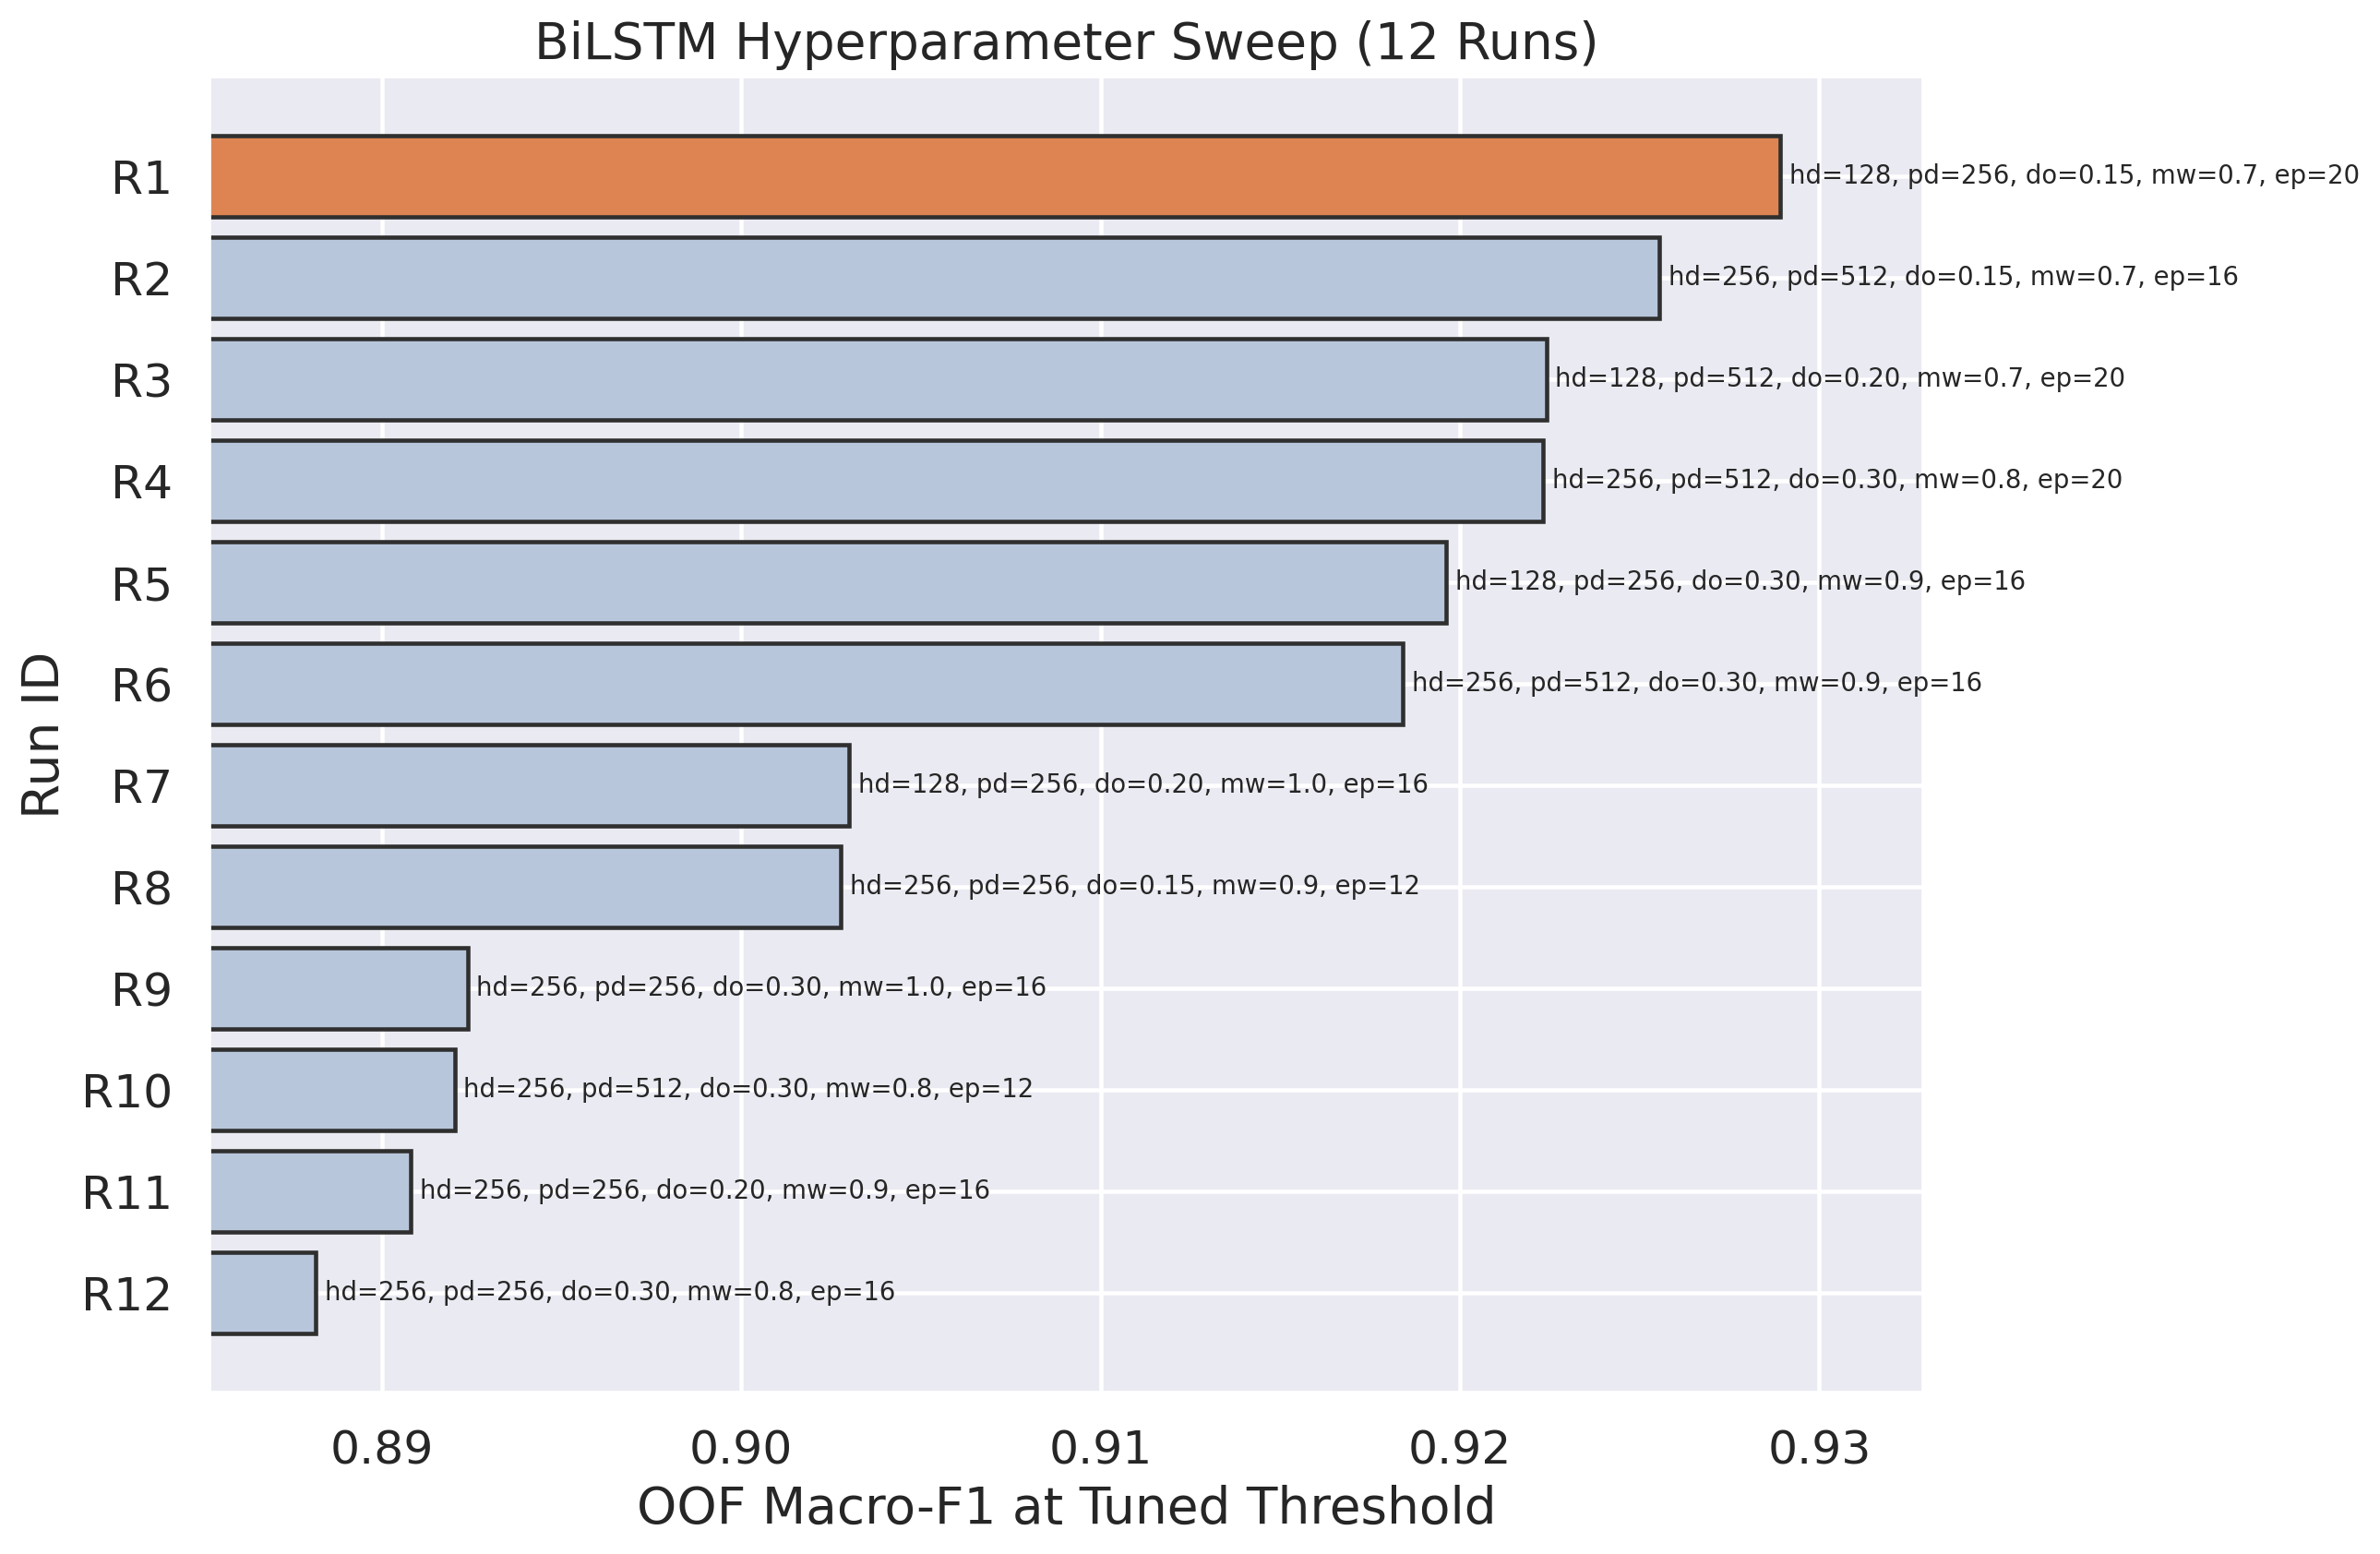

In [5]:
plot_frame = simple_sweep_frame.sort_values("oof_f1_macro_tuned", ascending=True).copy()

figsize = (12, 8)
text_dx = 0.00025
text_fontsize = 9
title = "BiLSTM Hyperparameter Sweep (12 Runs)"
highlight_run_id = "R1"
bar_color = "#b8c6db"
highlight_color = "#dd8452"

fig, ax = plt.subplots(figsize=figsize)
colors = [bar_color] * len(plot_frame)
highlight_pos = plot_frame.index[plot_frame["plot_id"] == highlight_run_id][0]
colors[list(plot_frame.index).index(highlight_pos)] = highlight_color

ax.barh(plot_frame["plot_id"], plot_frame["oof_f1_macro_tuned"], color=colors, edgecolor="#2f2f2f")
ax.set_xlabel("OOF Macro-F1 at Tuned Threshold")
ax.set_ylabel("Run ID")
ax.set_title(title)
ax.set_xlim(plot_frame["oof_f1_macro_tuned"].min() - 0.003, plot_frame["oof_f1_macro_tuned"].max() + 0.004)

for _, row in plot_frame.iterrows():
    ax.text(
        row["oof_f1_macro_tuned"] + text_dx,
        row["plot_id"],
        row["short_label"],
        va="center",
        fontsize=text_fontsize,
    )

fig.tight_layout()
render_figure(fig)
plt.close(fig)
# save_figure(fig, "simple_sweep_ranking_oof_custom")


## 2. Threshold Calibration

This figure explains why the final decision threshold is not fixed at 0.5.


In [6]:
sweep = pd.read_csv(best_run_dir / "threshold_sweep.csv")
best_row = sweep.sort_values(["f1_macro", "balanced_accuracy", "threshold"], ascending=[False, False, True]).iloc[0]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sweep["threshold"], sweep["f1_macro"], label="Macro-F1", linewidth=2.2, color="#dd8452")
ax.plot(sweep["threshold"], sweep["accuracy"], label="Accuracy", linewidth=2.2, color="#4c72b0")
ax.plot(sweep["threshold"], sweep["balanced_accuracy"], label="Balanced Accuracy", linewidth=2.2, color="#55a868")
ax.axvline(best_row["threshold"], color="#2f2f2f", linestyle="--", linewidth=1.5)
ax.text(float(best_row["threshold"]) + 0.003, float(best_row["f1_macro"]) - 0.003, f"best={best_row['threshold']:.3f}", fontsize=10)
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title("Threshold Calibration on Out-of-Fold Predictions")
ax.legend(frameon=True)
fig.tight_layout()
render_figure(fig)
plt.close(fig)
# save_figure(fig, "simple_threshold_sweep_custom")


NameError: name 'best_run_dir' is not defined

## 3. Epoch Selection

This plot compares the tuned-threshold validation score, the 0.5-threshold validation score, and the training loss across epochs.


In [7]:
history = pd.read_json(best_run_dir / "history.jsonl", lines=True)
history["validation_f1_tuned"] = history["validation_selection"].map(lambda value: value["f1_macro"])
history["validation_f1_0p5"] = history["validation_metrics_at_0p5"].map(lambda value: value["f1_macro"])
best_epoch = int(history.loc[history["validation_f1_tuned"].idxmax(), "epoch"])

fig, ax1 = plt.subplots(figsize=(10.5, 6.2))
ax1.plot(history["epoch"], history["validation_f1_tuned"], marker="o", linewidth=2.5, markersize=9, label="Validation Macro-F1 (tuned)", color="#dd8452")
ax1.plot(history["epoch"], history["validation_f1_0p5"], marker="s", linewidth=2.5, markersize=9, label="Validation Macro-F1 (0.5)", color="#4c72b0")
ax1.axvline(best_epoch, color="#2f2f2f", linestyle="--", linewidth=1.4)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Validation Macro-F1")
ax1.set_title("Epoch Selection for the Chosen BiLSTM")
ax1.set_xlim(history["epoch"].min() - 0.4, history["epoch"].max() + 0.4)
ax1.set_ylim(history[["validation_f1_tuned", "validation_f1_0p5"]].min().min() - 0.01, history[["validation_f1_tuned", "validation_f1_0p5"]].max().max() + 0.01)

ax2 = ax1.twinx()
ax2.plot(history["epoch"], history["train_loss"], marker="^", linewidth=2.3, markersize=8, alpha=0.6, label="Train Loss", color="#55a868")
ax2.set_ylabel("Train Loss")
ax2.set_ylim(history["train_loss"].min() * 0.9, history["train_loss"].max() * 1.05)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=True, columnspacing=1.4, handlelength=2.8)
fig.tight_layout(rect=(0, 0.08, 1, 1))
render_figure(fig)
plt.close(fig)
# save_figure(fig, "simple_epoch_selection_custom")


NameError: name 'best_run_dir' is not defined

## 4. Fold Stability

This heatmap summarizes the selected BiLSTM across the five grouped out-of-fold splits.


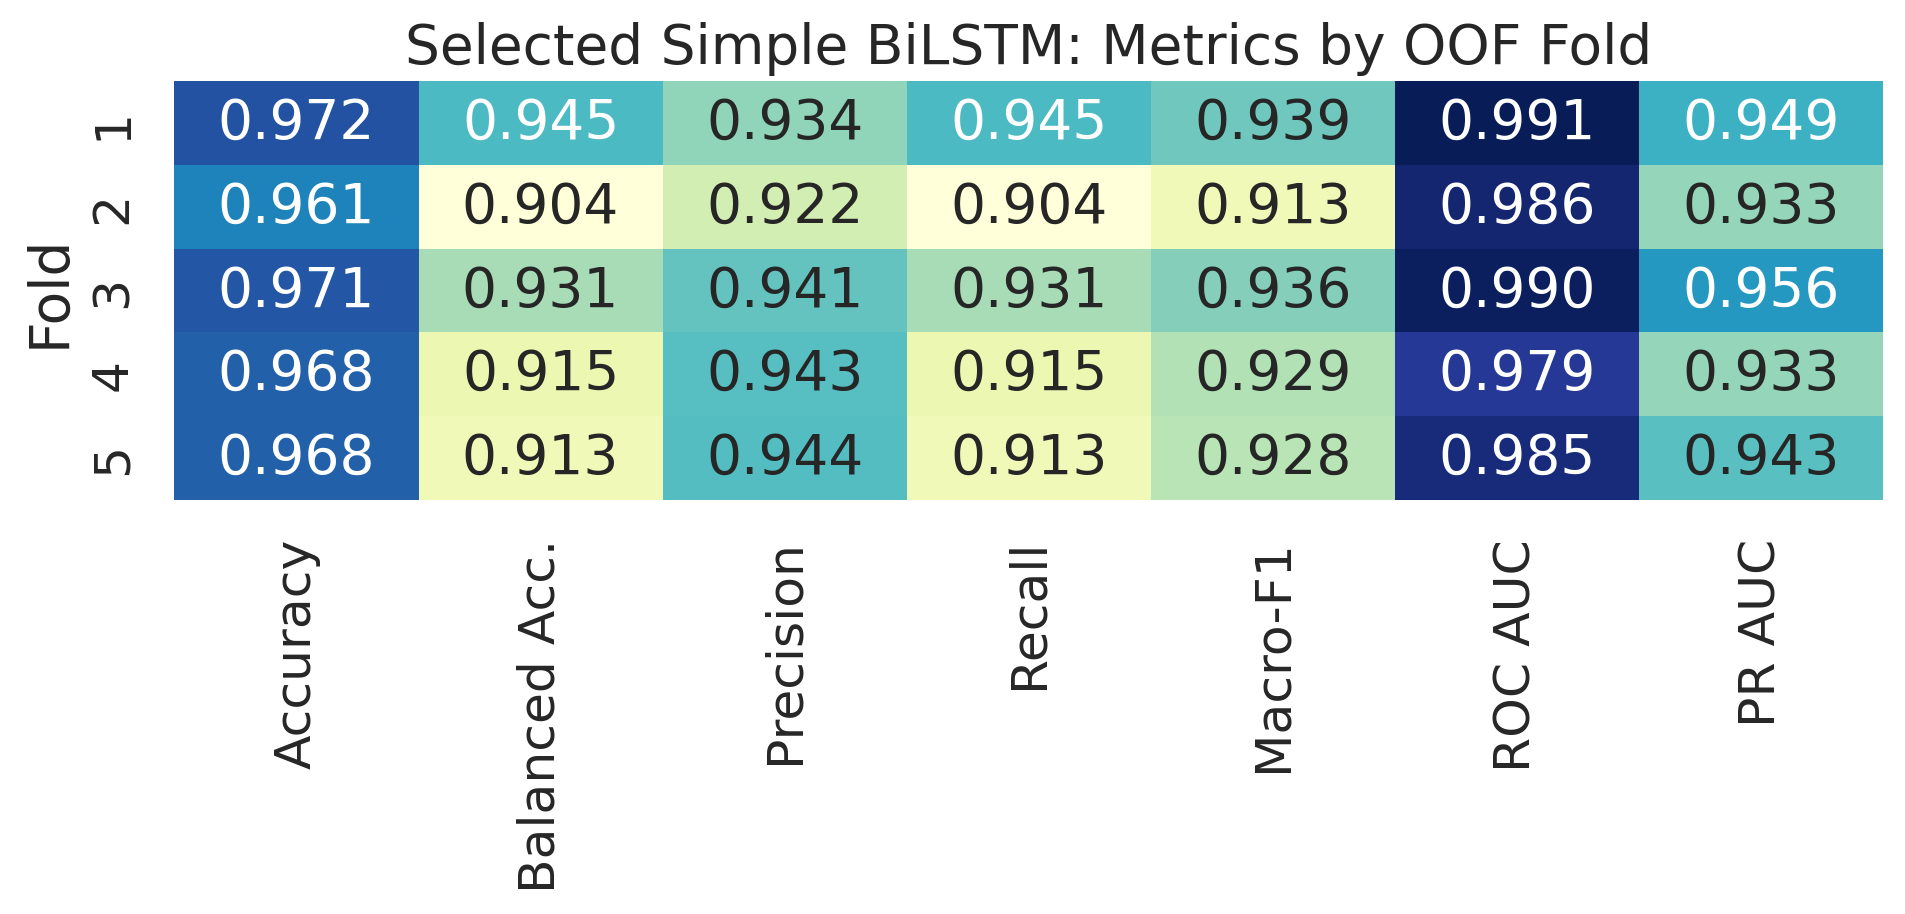

In [ ]:
heatmap_frame = best_fold_metrics.set_index("fold")[[
    "accuracy",
    "balanced_accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "roc_auc",
    "pr_auc",
]].rename(columns={
    "accuracy": "Accuracy",
    "balanced_accuracy": "Balanced Acc.",
    "precision_macro": "Precision",
    "recall_macro": "Recall",
    "f1_macro": "Macro-F1",
    "roc_auc": "ROC AUC",
    "pr_auc": "PR AUC",
})

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(heatmap_frame, annot=True, fmt=".3f", cmap="YlGnBu", cbar=False, ax=ax)
ax.set_title("Selected BiLSTM: Metrics by OOF Fold")
ax.set_xlabel("")
ax.set_ylabel("Fold")
fig.tight_layout()
render_figure(fig)
plt.close(fig)
# save_figure(fig, "simple_fold_metrics_heatmap_custom")


## 5. ROC and Precision-Recall Curves

These curves compare the report-safe out-of-fold discrimination quality of the main models side by side, with tuned-threshold operating points marked on each curve. The second figure below focuses on the BiLSTM family, including the best structured variant.


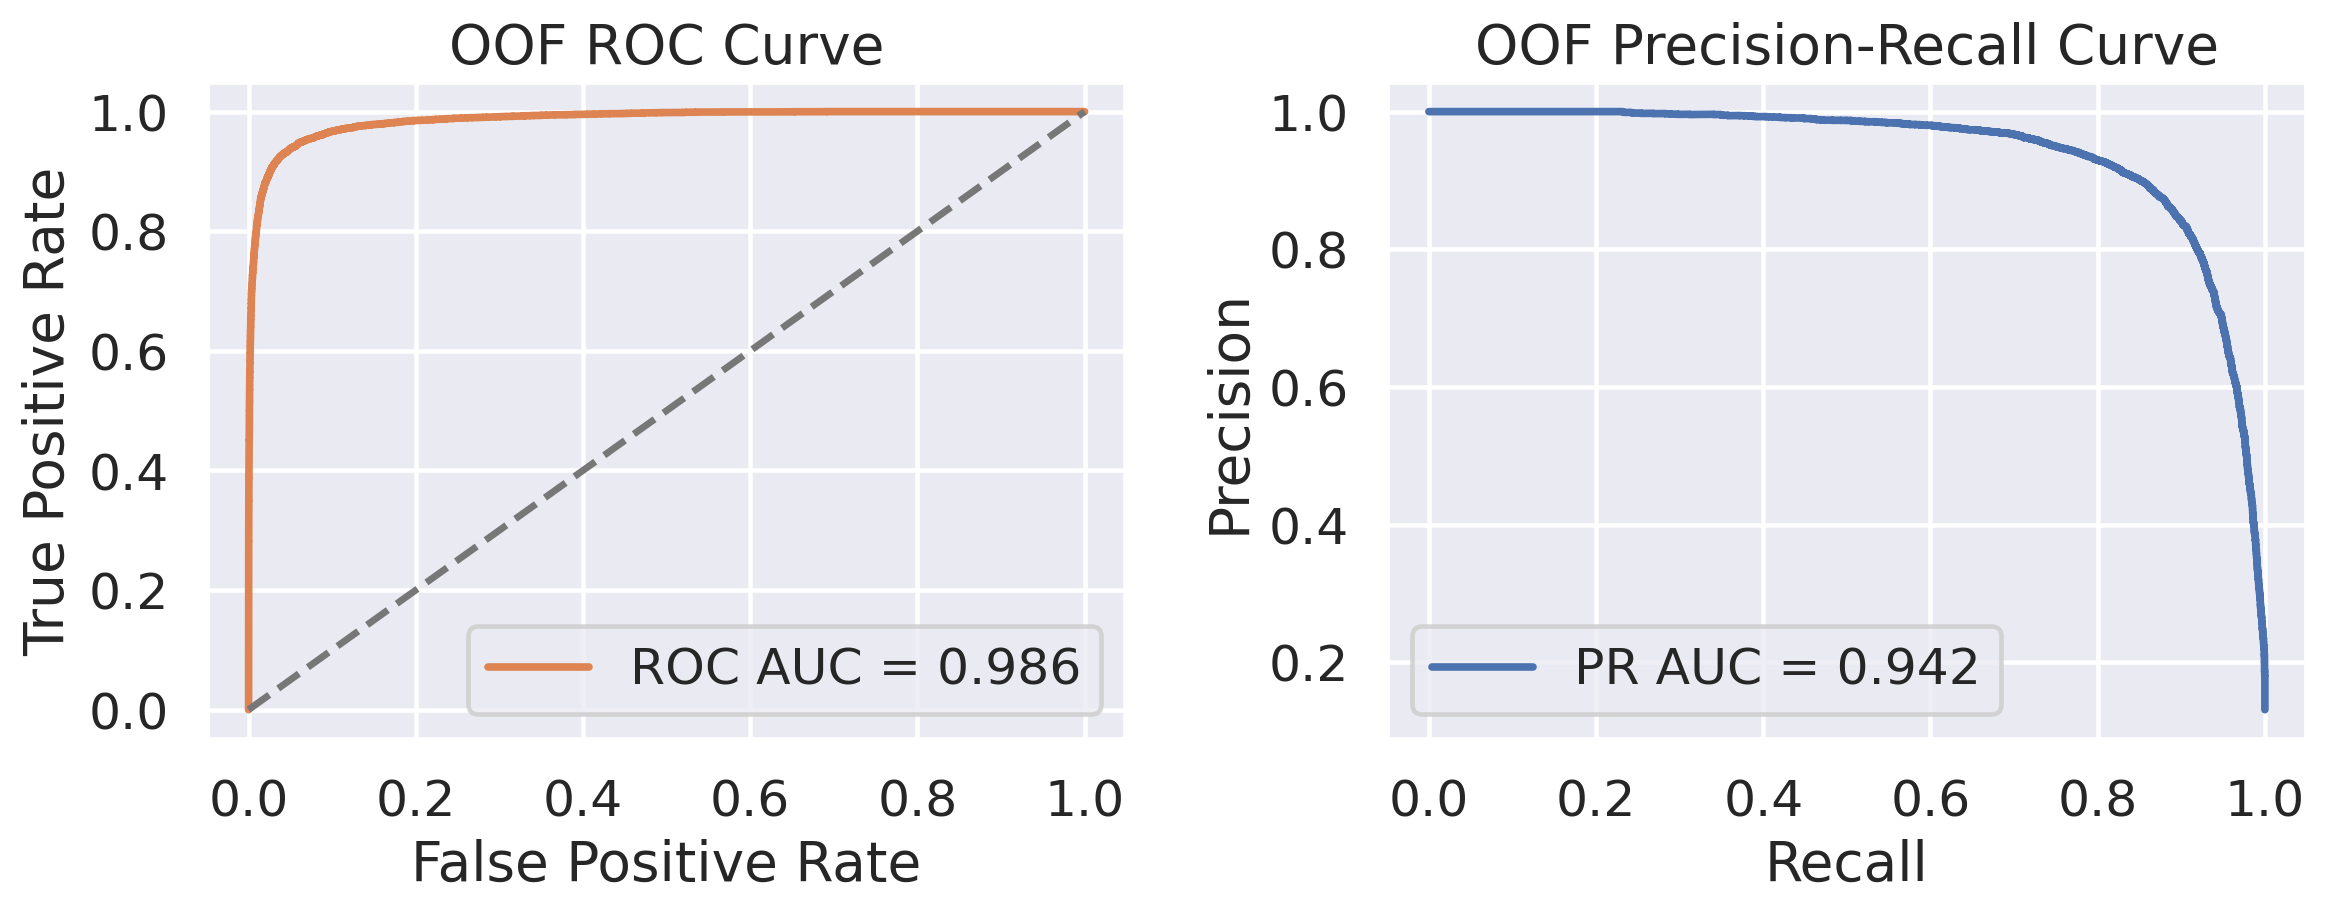

In [ ]:
fig = assets.plot_model_roc_pr_comparison(curve_sources)
render_figure(fig)
plt.close(fig)
# save_figure(fig, "model_comparison_roc_pr_oof_custom")

fig = assets.plot_structured_roc_pr_comparison(structured_curve_sources)
render_figure(fig)
plt.close(fig)
# save_figure(fig, "structured_model_roc_pr_oof_custom")


## 6. Boundary Diagnostics

This histogram zooms into the central lag window so the selected BiLSTM and a clearly worse-boundary BiLSTM are easier to compare visually.


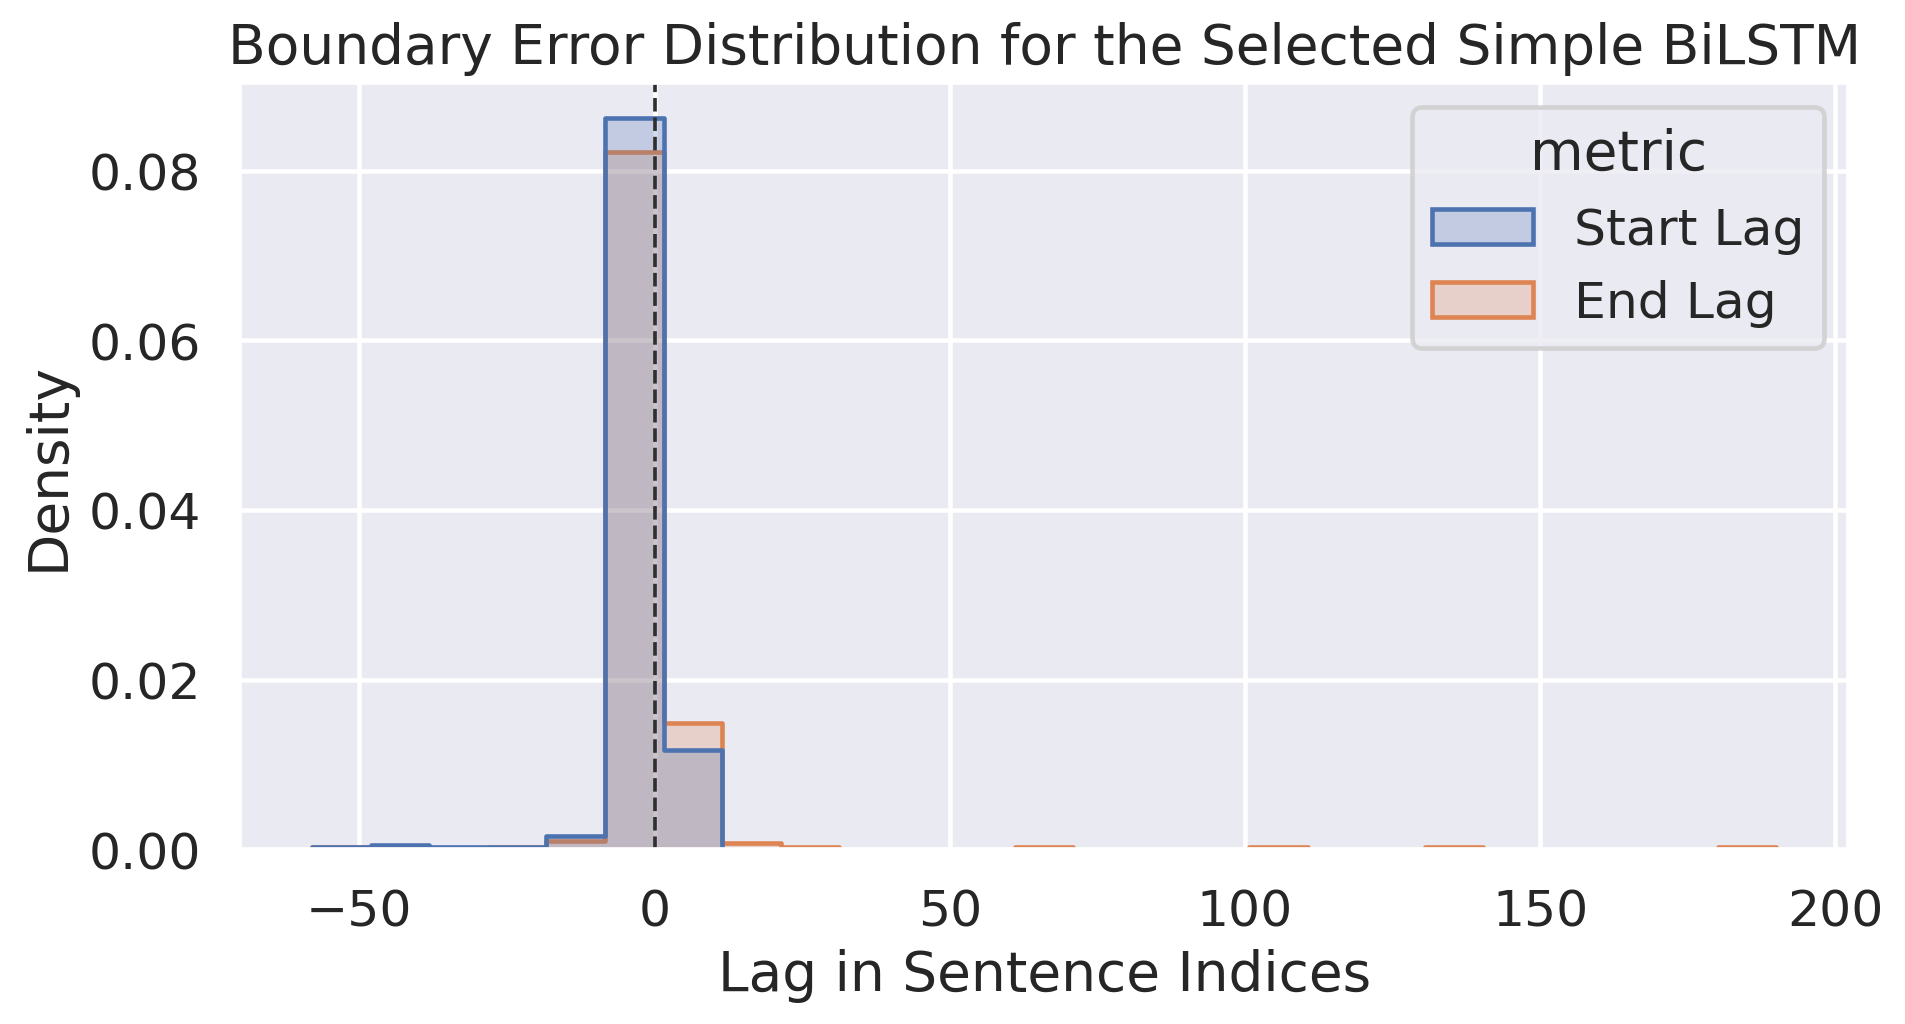

In [ ]:
fig = assets.plot_lag_distributions(
    speech_metrics,
    comparison_speech_metrics=boundary_comparison_run["speech_metrics"],
)
render_figure(fig)
plt.close(fig)
# save_figure(fig, "simple_boundary_lags_custom")


## 7. Sentence-Level Probability Trajectories

These two examples compare the calibrated BiLSTM, CamemBERT, and weighted fusion on representative speeches from the training set.


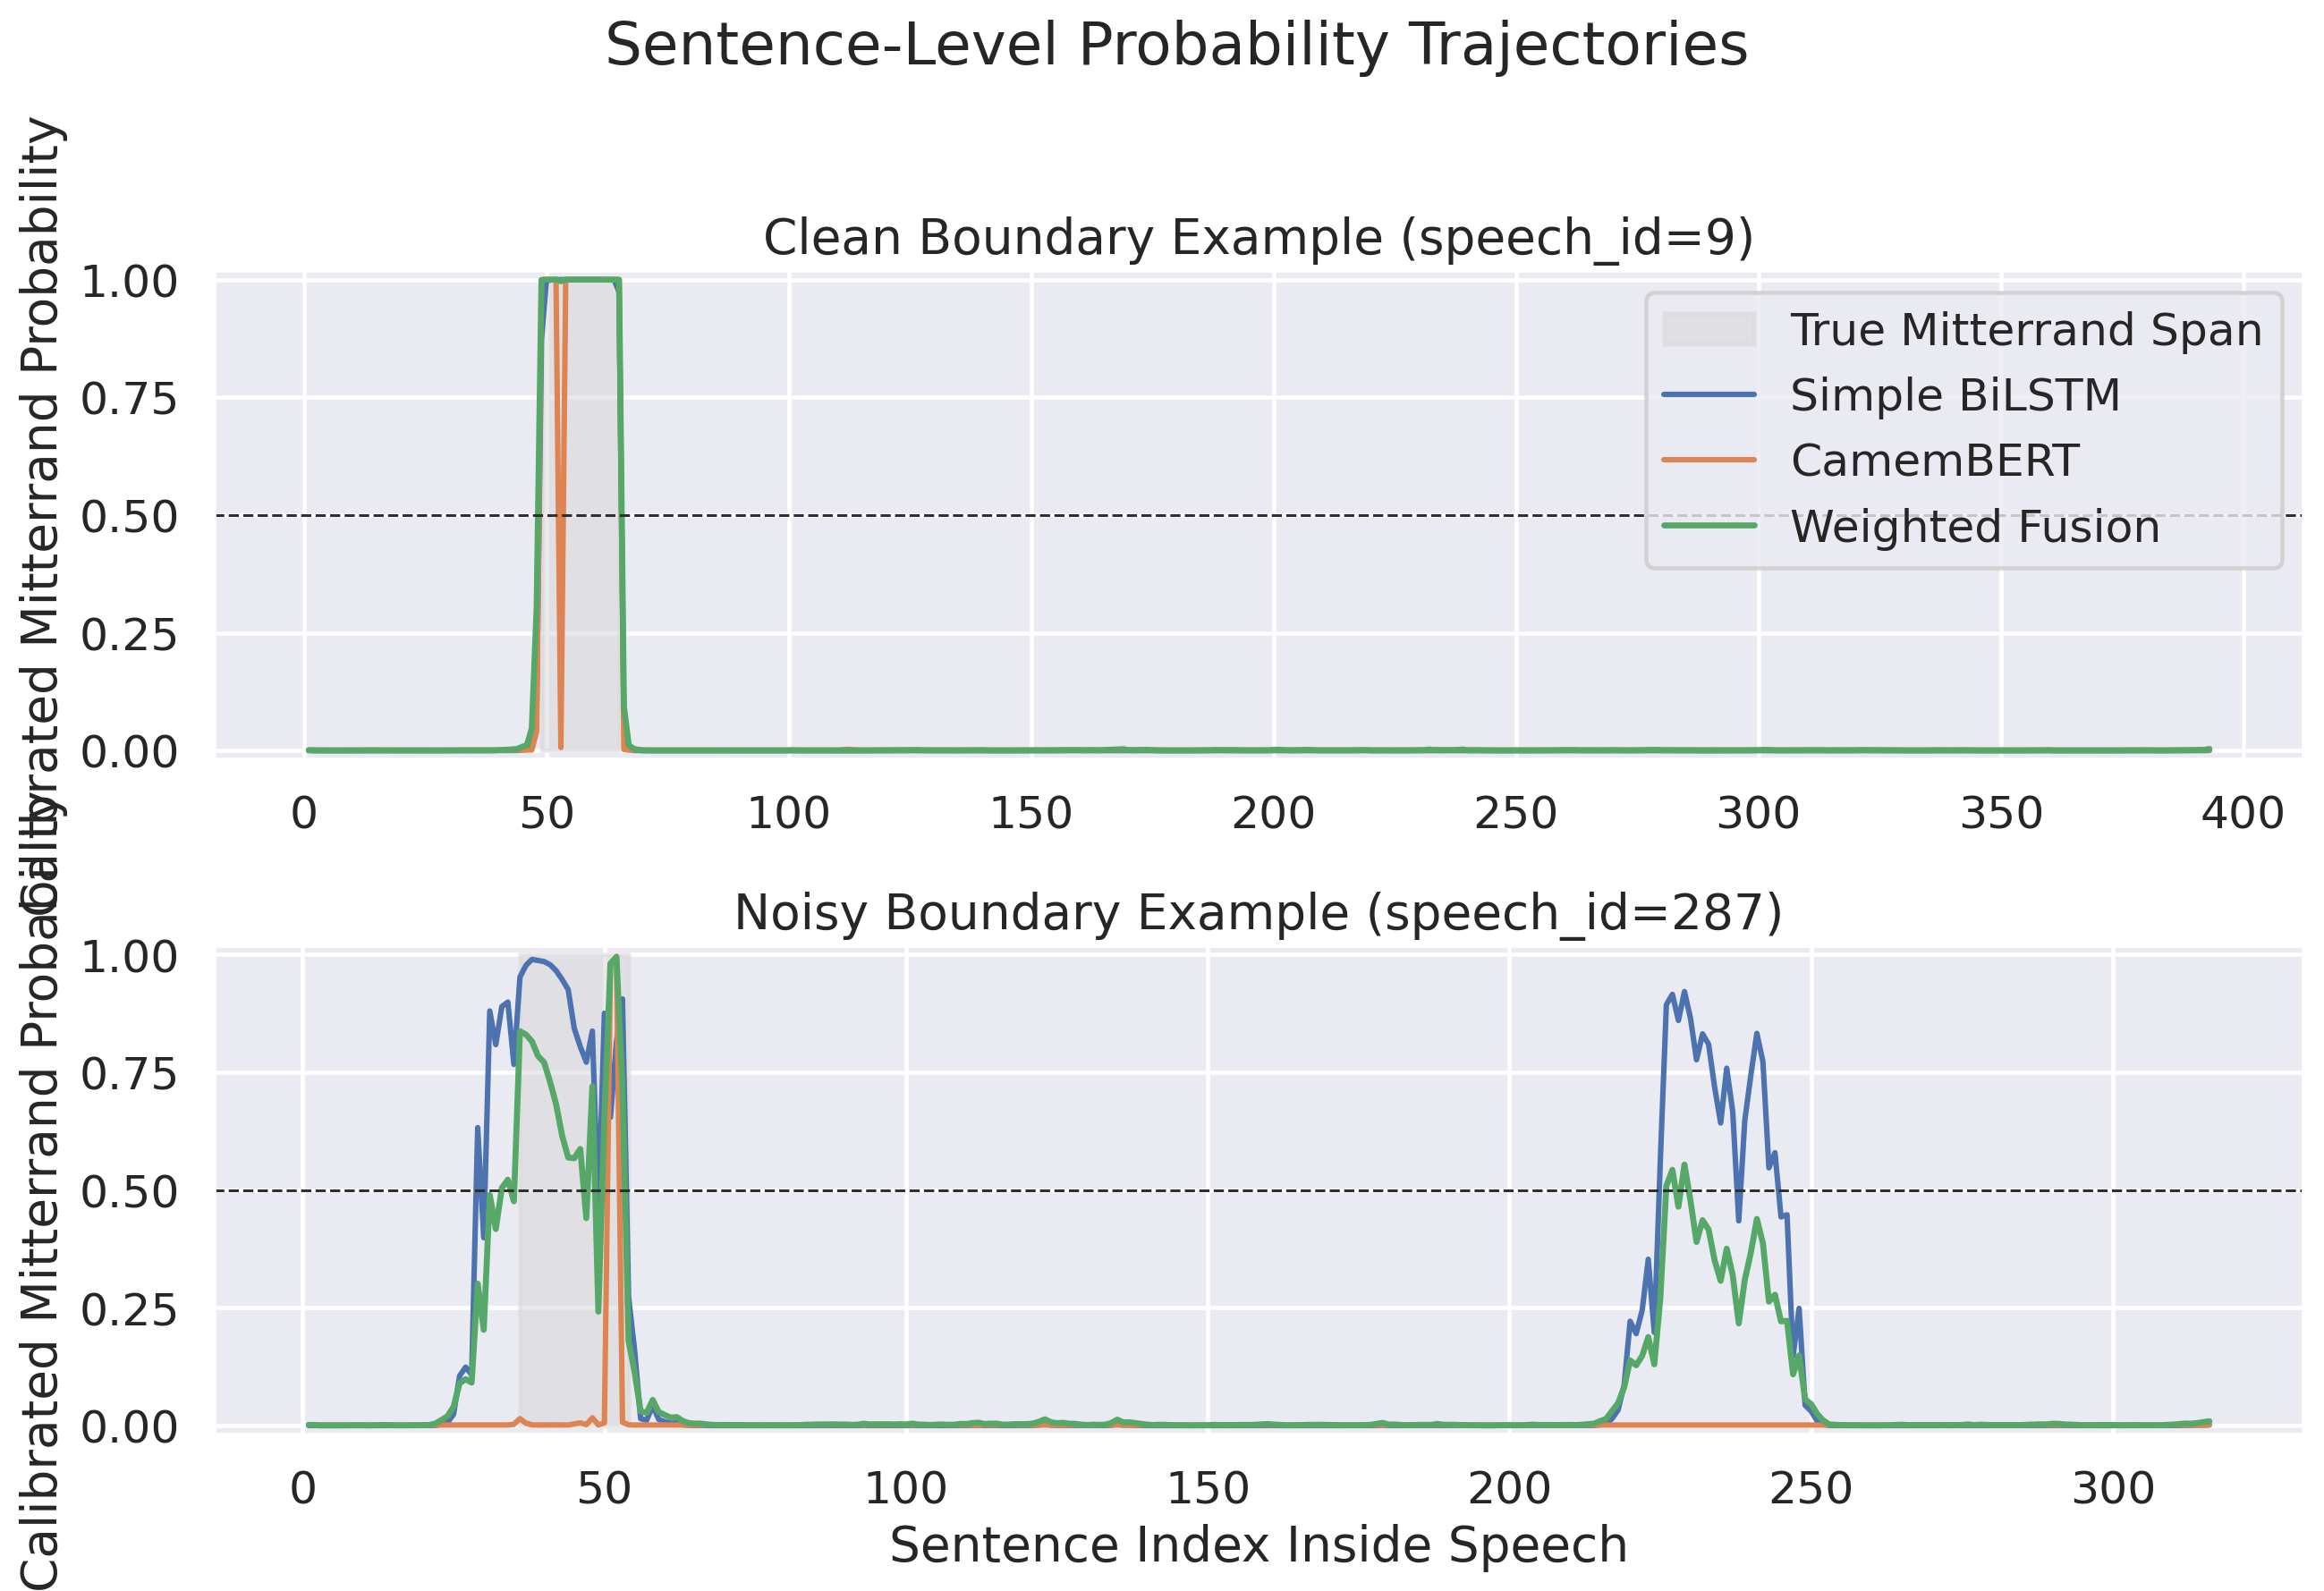

In [ ]:
fig = assets.plot_probability_trajectories(
    trajectory_frame,
    (clean_example_speech, noisy_example_speech),
)
render_figure(fig)
plt.close(fig)
# save_figure(fig, "probability_trajectories_examples_custom")


## 8. Model Comparison on Out-of-Fold Predictions

This bar chart compares the main models on the same grouped out-of-fold evaluation setup, and the table below prints a paper-style LaTeX version closer to the layout used in the other notebooks.


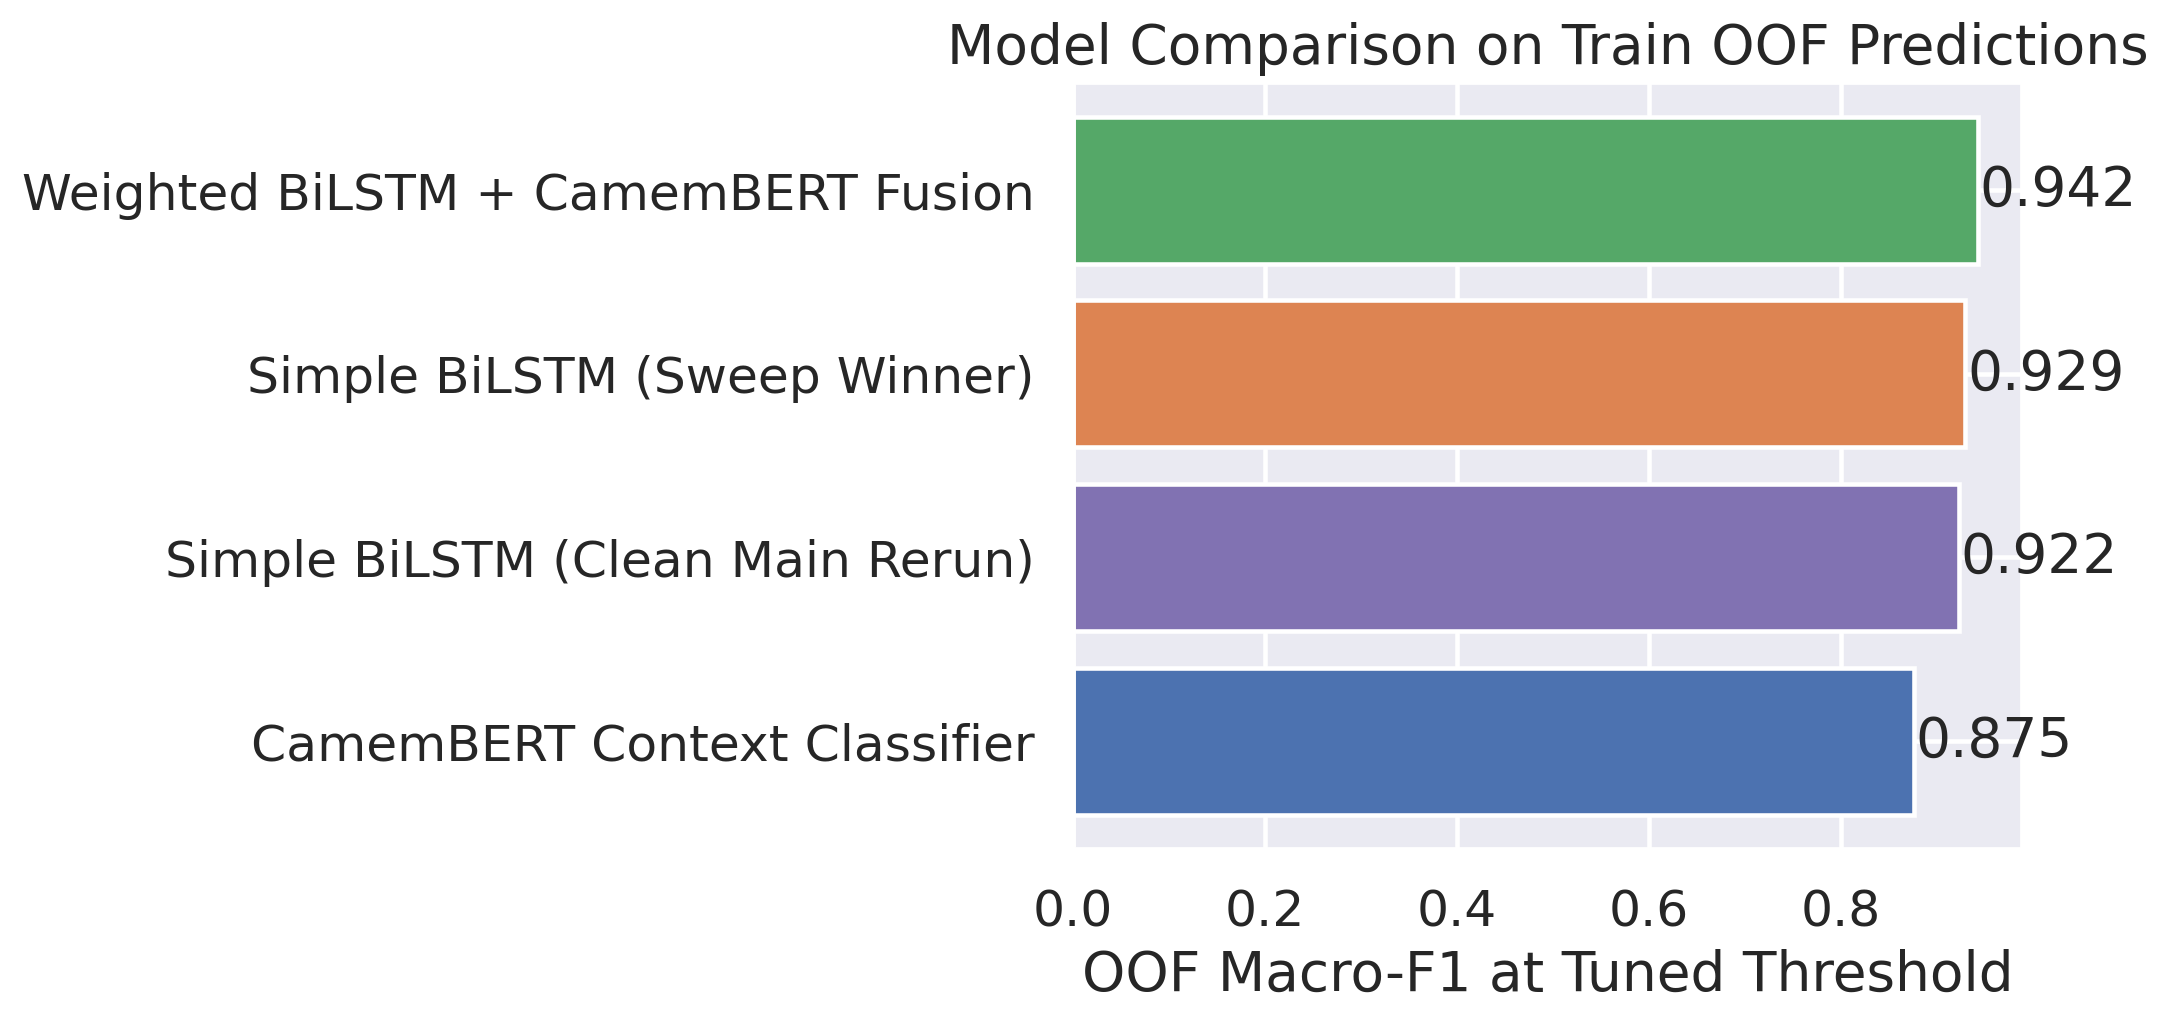

In [ ]:
plot_frame = model_comparison_frame.sort_values("oof_f1_macro", ascending=True).copy()

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(plot_frame["model"], plot_frame["oof_f1_macro"], color=[assets.MODEL_COLOR_MAP[model] for model in plot_frame["model"]])
ax.set_xlabel("OOF Macro-F1 at Tuned Threshold")
ax.set_title("Model Comparison on Train OOF Predictions")
for _, row in plot_frame.iterrows():
    ax.text(row["oof_f1_macro"] + 0.002, row["model"], f"{row['oof_f1_macro']:.3f}", va="center")
fig.tight_layout()
render_figure(fig)
plt.close(fig)
# save_figure(fig, "model_comparison_oof_custom")

display(camera_ready_table)
print(camera_ready_latex)


## 9. Fusion Weight Sweep

This plot shows how the weighted-average fusion performs as the BiLSTM weight varies.


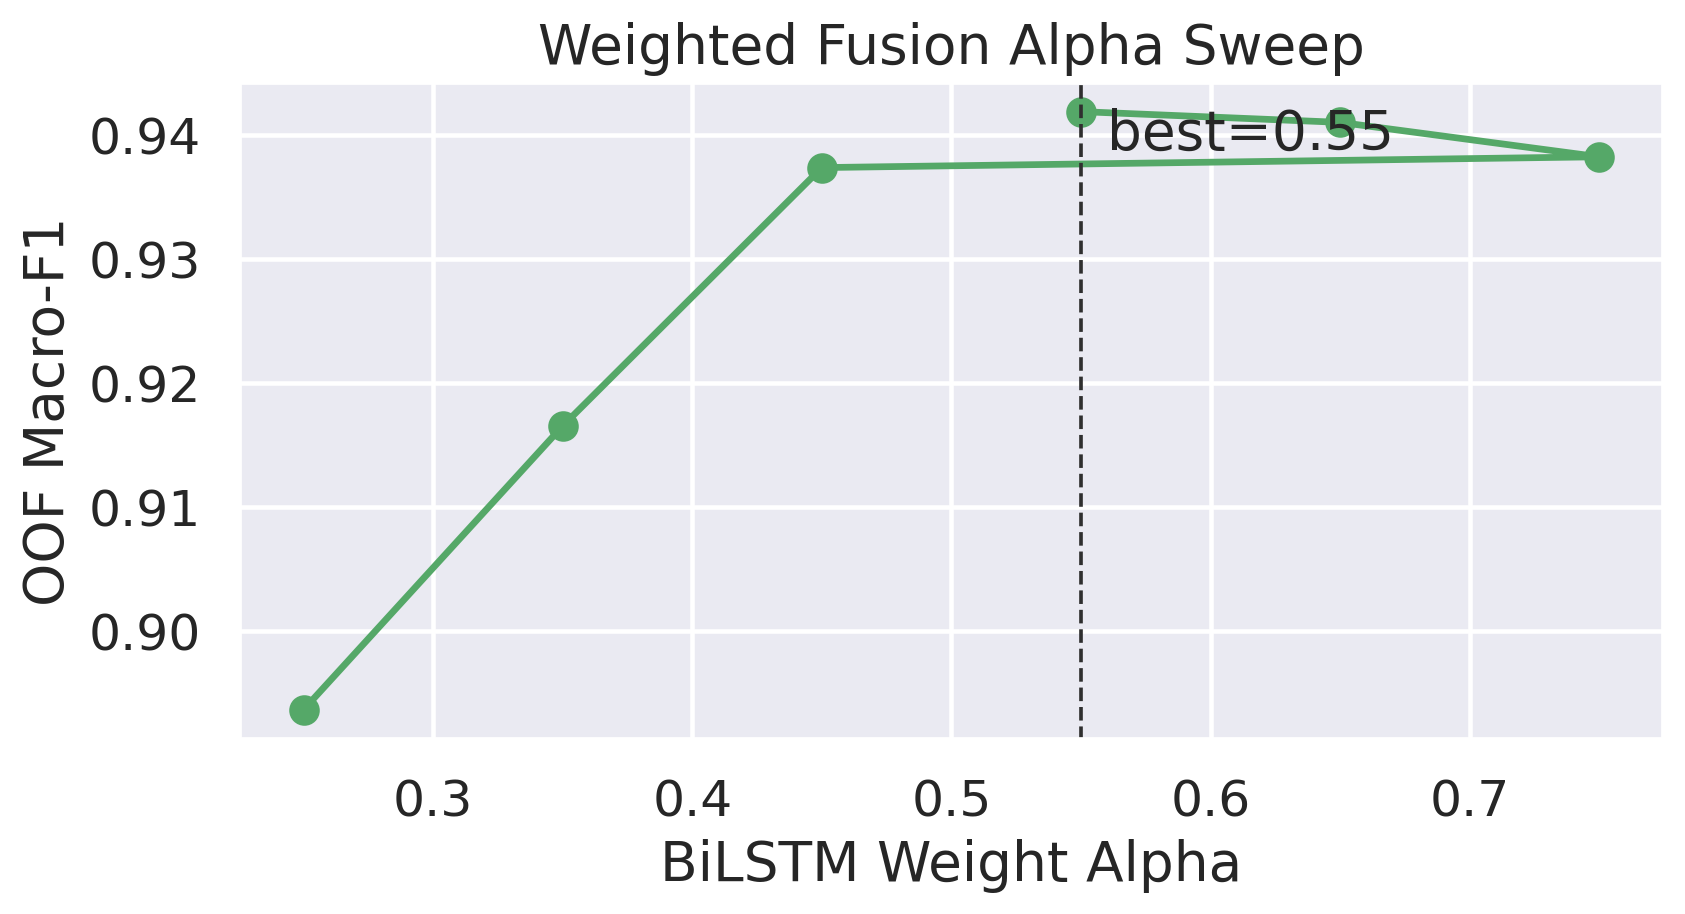

In [ ]:
alpha_sweep = pd.read_csv(fusion_source_dir / "alpha_sweep.csv")
best_alpha_row = alpha_sweep.sort_values(["f1_macro", "balanced_accuracy", "alpha"], ascending=[False, False, True]).iloc[0]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(alpha_sweep["alpha"], alpha_sweep["f1_macro"], marker="o", linewidth=2.2, color="#55a868")
ax.axvline(best_alpha_row["alpha"], color="#2f2f2f", linestyle="--", linewidth=1.2)
ax.set_xlabel("BiLSTM Weight Alpha")
ax.set_ylabel("OOF Macro-F1")
ax.set_title("Weighted Fusion Alpha Sweep")
ax.text(float(best_alpha_row["alpha"]) + 0.01, float(best_alpha_row["f1_macro"]) - 0.003, f"best={best_alpha_row['alpha']:.2f}")
fig.tight_layout()
render_figure(fig)
plt.close(fig)
# save_figure(fig, "fusion_alpha_sweep_custom")


## 10. Rebuild the Baseline Bundle

If you want to regenerate the default bundle after manual figure exploration, you can call the batch builder below.


In [ ]:
# assets.main()
